# Descriptive Survey Statistics

In [1]:
import pandas as pd
import numpy as np
import json

import matplotlib.pyplot as plt

In [2]:
survey = pd.read_csv("/Users/tonyvo/Desktop/Thesis/survey/survey_recoded.csv")
df = survey.copy()

print(len(df))
print(df.columns.tolist())

def make_distribution(data, col):
    counts = data[col].dropna().value_counts().sort_index()
    probs = data[col].dropna().value_counts(normalize=True).sort_index()

    dist = pd.DataFrame({
        col: counts.index,
        "count": counts.values,
        "probability": probs.values,
        "percentage": probs.values * 100
    })

    return dist

33
['timestamp', 'contact_email', 'age_group', 'postcode4', 'residence_length', 'daily_status', 'main_mode', 'daily_place_access', 'schedule_fixedness', 'free_time_after_activity', 'free_time_activity', 'transport_changed_timeplace', 'casual_place_access', 'pass_stop_places_freq', 'spontaneous_stop_ease', 'five_min_detour_likely', 'detour_tolerance_mins', 'main_stop_barrier', 'regular_use_barriers', 'third_place_visit_freq', 'visit_planning_type', 'linger_freq', 'place_type_used', 'main_place_reason', 'same_place_return_freq', 'recognized_regular', 'familiar_faces_freq', 'small_interactions_freq', 'ease_public_places', 'social_use_type', 'belonging', 'place_familiarity', 'comfort_no_purpose', 'unstructured_time', 'too_rushed', 'transport_enables_local_time', 'transport_encourages_direct_travel', 'comfortable_place_text', 'barriers_text', 'transport_routines_social_life_text', 'faster_travel_effect_text', 'regular_visit_origin_text']


# Individual Level Analysis

## Parameter 1 — transport mode share

In [3]:
sim_modes = ["Walking", "Bicycle", "Car"]

df_sim = df[df["main_mode"].isin(sim_modes)].copy()

print("Original responses:", len(df))
print("Simulation-mode responses:", len(df_sim))
print(df_sim["main_mode"].value_counts(dropna=False))

Original responses: 33
Simulation-mode responses: 24
main_mode
Bicycle    19
Walking     4
Car         1
Name: count, dtype: int64


In [4]:
mode_distribution = make_distribution(df_sim, "main_mode")

mode_distribution

,main_mode,count,probability,percentage
0,Bicycle,19,0.791667,79.166667
1,Car,1,0.041667,4.166667
2,Walking,4,0.166667,16.666667


## Parameter 2 — casual stopping probability

In [5]:
df_sim["p_casual_stop"] = (df_sim["pass_stop_places_freq"] - 1) / 4
df_sim["p_casual_stop"] = df_sim["p_casual_stop"].clip(0, 1)

baseline_p_casual_stop = df_sim["p_casual_stop"].mean()

print("Baseline casual stopping probability:", baseline_p_casual_stop)

p_stop_by_mode = df_sim.groupby("main_mode")["p_casual_stop"].agg(
    ["count", "mean", "std"]
)

p_stop_by_mode

Baseline casual stopping probability: 0.8020833333333334


,count,mean,std
main_mode,,,
Bicycle,19,0.828947,0.16776
Car,1,0.750000,NaN
Walking,4,0.687500,0.12500


## Parameter 3 — detour tolerance

In [6]:
detour_minutes_map = {
    1: 0,
    2: 3,
    3: 7.5,
    4: 12.5,
    5: 17.5
}

df_sim["detour_tolerance_minutes_est"] = df_sim["detour_tolerance_mins"].map(detour_minutes_map)
detour_distribution = make_distribution(df, "detour_tolerance_mins")

detour_distribution

,detour_tolerance_mins,count,probability,percentage
0,2.0,3,0.130435,13.043478
1,3.0,11,0.478261,47.826087
2,4.0,8,0.347826,34.782609
3,5.0,1,0.043478,4.347826


## Parameter 4 — same-place return tendency

In [7]:
df_sim["p_return_same_place"] = (df_sim["same_place_return_freq"] - 1) / 4
df_sim["p_return_same_place"] = df_sim["p_return_same_place"].clip(0, 1)

baseline_p_return_same_place = df_sim["p_return_same_place"].mean()

print("Baseline return-to-same-place probability:", baseline_p_return_same_place)

return_distribution = make_distribution(df, "same_place_return_freq")

return_distribution

Baseline return-to-same-place probability: 0.3854166666666667


,same_place_return_freq,count,probability,percentage
0,1,5,0.151515,15.151515
1,2,13,0.393939,39.393939
2,3,10,0.303030,30.303030
3,4,5,0.151515,15.151515


## Parameter 5 - free time after main activity

In [8]:
free_time_distribution = make_distribution(df, "free_time_after_activity")

free_time_distribution

free_time_minutes_map = {
    0: 0,
    1: 10,
    2: 22.5,
    3: 45,
    4: 75
}

df["free_time_minutes_est"] = df["free_time_after_activity"].map(free_time_minutes_map)
df_sim["free_time_minutes_est"] = df_sim["free_time_after_activity"].map(free_time_minutes_map)

dist = make_distribution(df_sim, "free_time_minutes_est")
dist

,free_time_minutes_est,count,probability,percentage
0,10.0,3,0.3,30.0
1,22.5,2,0.2,20.0
2,45.0,1,0.1,10.0
3,75.0,4,0.4,40.0


## Parameter 6 - Stranger Interaction

In [9]:
df_sim["p_stranger_interaction"] = df_sim["small_interactions_freq"] / 2
df_sim["p_stranger_interaction"] = df_sim["p_stranger_interaction"].clip(0, 1)

baseline_p_stranger_interaction = df_sim["p_stranger_interaction"].mean()

print("Baseline stranger interaction probability:", baseline_p_stranger_interaction)


Baseline stranger interaction probability: 0.8958333333333334


In [19]:
dist = make_distribution(df_sim, "p_stranger_interaction")
dist

,p_stranger_interaction,count,probability,percentage
0,0.5,5,0.208333,20.833333
1,1.0,19,0.791667,79.166667


## Full Clean Table

In [11]:
parameter_sources = {
    "p_casual_stop": df_sim["p_casual_stop"],
    "detour_tolerance_minutes": df_sim["detour_tolerance_minutes_est"],
    "p_return_same_place": df_sim["p_return_same_place"],
    "free_time_minutes": df_sim["free_time_minutes_est"],
    "p_stranger_interaction": df_sim["p_stranger_interaction"]
}

rows = []

for parameter, series in parameter_sources.items():
    valid = series.dropna()
    n = valid.count()
    mean = valid.mean()
    median = valid.median()
    
    counts = valid.value_counts().sort_index()
    
    for value, count in counts.items():
        rows.append({
            "parameter": parameter,
            "value": value,
            "count": count,
            "percentage": (count / n) * 100,
            "mean": mean,
            "median": median,
            "n": n
        })

parameter_distribution_summary = pd.DataFrame(rows)

parameter_distribution_summary["percentage"] = parameter_distribution_summary["percentage"].round(2)
parameter_distribution_summary["mean"] = parameter_distribution_summary["mean"].round(3)
parameter_distribution_summary["median"] = parameter_distribution_summary["median"].round(3)

parameter_distribution_summary

,parameter,value,count,percentage,mean,median,n
0,p_casual_stop,0.50,3,12.50,0.802,0.750,24
1,p_casual_stop,0.75,13,54.17,0.802,0.750,24
2,p_casual_stop,1.00,8,33.33,0.802,0.750,24
3,detour_tolerance_minutes,3.00,3,16.67,8.417,7.500,18
4,detour_tolerance_minutes,7.50,9,50.00,8.417,7.500,18
5,detour_tolerance_minutes,12.50,6,33.33,8.417,7.500,18
6,p_return_same_place,0.00,2,8.33,0.385,0.375,24
7,p_return_same_place,0.25,10,41.67,0.385,0.375,24
8,p_return_same_place,0.50,9,37.50,0.385,0.375,24
9,p_return_same_place,0.75,3,12.50,0.385,0.375,24


In [12]:
distribution_table = parameter_distribution_summary[
    ["parameter", "value", "count", "percentage"]
].copy()

label_maps = {
    "p_casual_stop": {
        0.00: "Never",
        0.25: "Rarely",
        0.50: "Sometimes",
        0.75: "Often",
        1.00: "Very often"
    },
    "detour_tolerance_minutes": {
        0.00: "0 minutes",
        3.00: "1-5 minutes",
        7.50: "5-10 minutes",
        12.50: "10-15 minutes",
        17.50: ">15 minutes"
    },
    "p_return_same_place": {
        0.00: "Never",
        0.25: "Rarely",
        0.50: "Sometimes",
        0.75: "Often",
        1.00: "Very often"
    },
    "free_time_minutes": {
        0.00: "None",
        10.00: "Less than 15 minutes",
        22.50: "15-30 minutes",
        45.00: "30-60 minutes",
        75.00: "More than 1 hour"
    },
    "p_stranger_interaction": {
        0.00: "No / known people only",
        0.50: "Sometimes interacts with unknown people",
        1.00: "Regularly interacts with unknown people"
    }
}

distribution_table["response_category"] = distribution_table.apply(
    lambda row: label_maps.get(row["parameter"], {}).get(row["value"], row["value"]),
    axis=1
)

distribution_table = distribution_table[
    ["parameter", "response_category", "count", "percentage"]
]

distribution_table



,parameter,response_category,count,percentage
0,p_casual_stop,Sometimes,3,12.50
1,p_casual_stop,Often,13,54.17
2,p_casual_stop,Very often,8,33.33
3,detour_tolerance_minutes,1-5 minutes,3,16.67
4,detour_tolerance_minutes,5-10 minutes,9,50.00
5,detour_tolerance_minutes,10-15 minutes,6,33.33
6,p_return_same_place,Never,2,8.33
7,p_return_same_place,Rarely,10,41.67
8,p_return_same_place,Sometimes,9,37.50
9,p_return_same_place,Often,3,12.50


# Third Place Level Analysis

In [13]:
third_place_ordinal_cols = [
    # attraction / accessibility
    "casual_place_access",
    "spontaneous_stop_ease",

    # use behaviour
    "third_place_visit_freq",
    "linger_freq",

    # transport-third-place relationship
    "transport_enables_local_time",
    "transport_encourages_direct_travel"
]

third_place_nominal_cols = [
    "visit_planning_type",
    "place_type_used",
    "main_stop_barrier",
]

third_place_multiselect_cols = [
    "regular_use_barriers"
]

# Labels
difficulty_labels = {
    1: "Very difficult",
    2: "Difficult",
    3: "Neutral",
    4: "Easy",
    5: "Very easy"
}

visit_freq_labels = {
    1: "Never",
    2: "Less than once a month",
    3: "1-3 times a month",
    4: "1-2 times a week",
    5: "3 or more times a week"
}

frequency_labels = {
    1: "Never",
    2: "Rarely",
    3: "Sometimes",
    4: "Often",
    5: "Very often"
}


ordinal_label_maps = {
    "casual_place_access": difficulty_labels,
    "third_place_visit_freq": visit_freq_labels,
    "linger_freq": frequency_labels,
    "familiar_faces_freq": frequency_labels
}

# Cleaner chart labels
chart_titles = {
    "casual_place_access": "Ease of Reaching Casual Third Places",
    "third_place_visit_freq": "Frequency of Visiting Local Third Places",
    "linger_freq": "Frequency of Staying Longer Than Intended",
    "familiar_faces_freq": "Frequency of Seeing Familiar Faces",
    "place_type_used": "Types of Third Places Used Most Often",
    "main_place_reason": "Main Reason for Using Local Third Places",
    "main_stop_barrier": "Main Barrier to Stopping in Local Places"
}


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

# Output folders
output_dir = Path("third_place_selected_outputs")
table_dir = output_dir / "tables"
chart_dir = output_dir / "charts"

table_dir.mkdir(parents=True, exist_ok=True)
chart_dir.mkdir(parents=True, exist_ok=True)

# Selected columns
selected_ordinal_cols = [
    "casual_place_access",
    "third_place_visit_freq",
    "linger_freq",
    "familiar_faces_freq"
]

selected_nominal_cols = [
    "place_type_used",
    "main_place_reason",
    "main_stop_barrier"
]

# Labels
difficulty_labels = {
    1: "Very difficult",
    2: "Difficult",
    3: "Neutral",
    4: "Easy",
    5: "Very easy"
}

visit_freq_labels = {
    1: "Never",
    2: "Less than once a month",
    3: "1-3 times a month",
    4: "1-2 times a week",
    5: "3 or more times a week"
}

frequency_labels = {
    1: "Never",
    2: "Rarely",
    3: "Sometimes",
    4: "Often",
    5: "Very often"
}

ordinal_label_maps = {
    "casual_place_access": difficulty_labels,
    "third_place_visit_freq": visit_freq_labels,
    "linger_freq": frequency_labels,
    "familiar_faces_freq": frequency_labels
}

# Cleaner chart labels
chart_titles = {
    "casual_place_access": "Ease of Reaching Casual Third Places",
    "third_place_visit_freq": "Frequency of Visiting Local Third Places",
    "linger_freq": "Frequency of Staying Longer Than Intended",
    "familiar_faces_freq": "Frequency of Seeing Familiar Faces",
    "place_type_used": "Types of Third Places Used Most Often",
    "main_place_reason": "Main Reason for Using Local Third Places",
    "main_stop_barrier": "Main Barrier to Stopping in Local Places"
}



In [ ]:
def wrap_text(x, width=35):
    return "\n".join(textwrap.wrap(str(x), width=width))

def make_distribution_table(data, col, label_map=None, ordinal=True):
    valid = data[col].dropna()

    counts = valid.value_counts()
    probs = valid.value_counts(normalize=True)

    table = pd.DataFrame({
        "value": counts.index,
        "count": counts.values,
        "probability": probs.values,
        "percentage": probs.values * 100
    })

    if label_map is not None:
        table["label"] = table["value"].map(label_map)
    else:
        table["label"] = table["value"].astype(str)

    if ordinal:
        table = table.sort_values("value")
    else:
        table = table.sort_values("count", ascending=False)

    return table[["value", "label", "count", "probability", "percentage"]]

def plot_bar_chart(table, title, output_path):
    labels = table["label"].apply(lambda x: wrap_text(x, 35))
    percentages = table["percentage"]

    plt.figure(figsize=(8, max(4, len(table) * 0.6)))
    plt.barh(labels, percentages)
    plt.xlabel("Percentage of respondents")
    plt.ylabel("")
    plt.title(title)
    plt.gca().invert_yaxis()

    for i, v in enumerate(percentages):
        plt.text(v + 0.5, i, f"{v:.1f}%", va="center")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

In [21]:
for col in selected_ordinal_cols:
    table = make_distribution_table(
        df,
        col,
        label_map=ordinal_label_maps[col],
        ordinal=True
    )

    table.to_csv(table_dir / f"{col}_distribution.csv", index=False)

    print(f"\n--- {chart_titles[col]} ---")
    print(f"\n--- Variable tag: {col} ---")
    display(table)



--- Ease of Reaching Casual Third Places ---

--- Variable tag: casual_place_access ---


,value,label,count,probability,percentage
0,1,Very difficult,20,0.606061,60.606061
1,2,Difficult,7,0.212121,21.212121
2,3,Neutral,4,0.121212,12.121212
3,4,Easy,2,0.060606,6.060606



--- Frequency of Visiting Local Third Places ---

--- Variable tag: third_place_visit_freq ---


,value,label,count,probability,percentage
3,1,Never,2,0.060606,6.060606
2,2,Less than once a month,2,0.060606,6.060606
0,3,1-3 times a month,15,0.454545,45.454545
1,4,1-2 times a week,13,0.393939,39.393939
4,5,3 or more times a week,1,0.030303,3.030303



--- Frequency of Staying Longer Than Intended ---

--- Variable tag: linger_freq ---


,value,label,count,probability,percentage
4,1,Never,1,0.030303,3.030303
2,2,Rarely,7,0.212121,21.212121
0,3,Sometimes,15,0.454545,45.454545
1,4,Often,8,0.242424,24.242424
3,5,Very often,2,0.060606,6.060606



--- Frequency of Seeing Familiar Faces ---

--- Variable tag: familiar_faces_freq ---


,value,label,count,probability,percentage
4,1,Never,2,0.060606,6.060606
1,2,Rarely,10,0.303030,30.303030
0,3,Sometimes,13,0.393939,39.393939
2,4,Often,6,0.181818,18.181818
3,5,Very often,2,0.060606,6.060606



--- Types of Third Places Used Most Often ---

--- Variable name: place_type_used ---


,value,label,count,probability,percentage
0,Café / coffee place,Café / coffee place,13,0.393939,39.393939
1,Park / square,Park / square,12,0.363636,36.363636
2,Bar / pub,Bar / pub,4,0.121212,12.121212
3,Gym / sports place,Gym / sports place,3,0.090909,9.090909
4,Library,Library,1,0.030303,3.030303


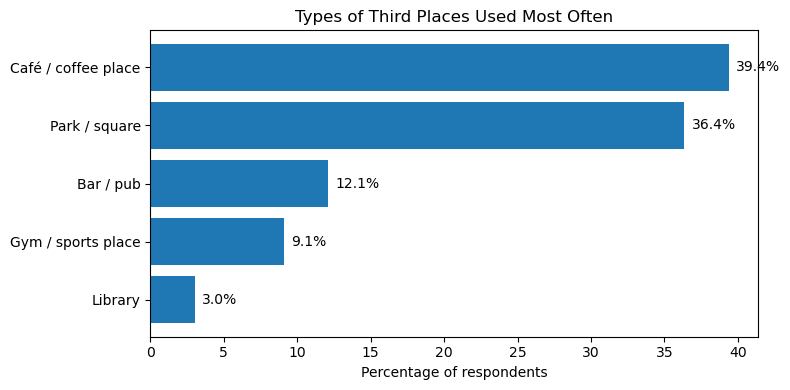


--- Main Reason for Using Local Third Places ---

--- Variable name: main_place_reason ---


,value,label,count,probability,percentage
0,To meet friends/family,To meet friends/family,16,0.484848,48.484848
1,To relax alone,To relax alone,8,0.242424,24.242424
2,To be around other people,To be around other people,4,0.121212,12.121212
3,To take a break while travelling,To take a break while travelling,1,0.030303,3.030303
4,All,All,1,0.030303,3.030303
5,to study,to study,1,0.030303,3.030303
6,Convenience on the way somewhere else,Convenience on the way somewhere else,1,0.030303,3.030303
7,Like to eat or drink out,Like to eat or drink out,1,0.030303,3.030303


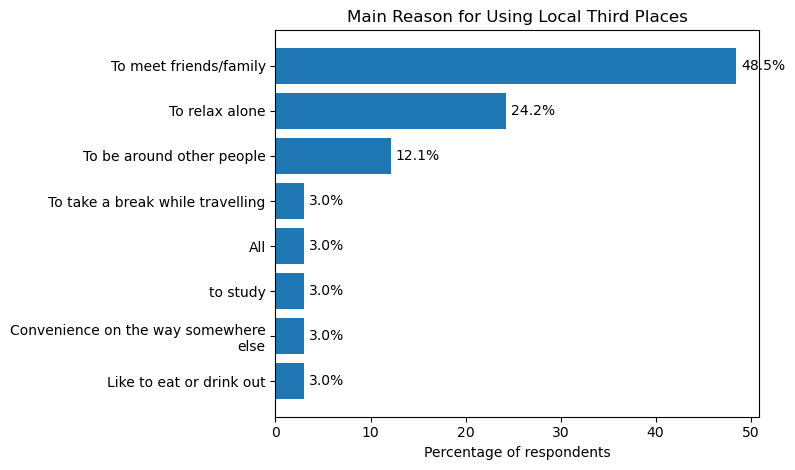


--- Main Barrier to Stopping in Local Places ---

--- Variable name: main_stop_barrier ---


,value,label,count,probability,percentage
0,Places are too expensive,Places are too expensive,15,0.454545,45.454545
1,I prefer going straight home,I prefer going straight home,8,0.242424,24.242424
2,Lack of time,Lack of time,7,0.212121,21.212121
3,Places are too far away,Places are too far away,3,0.090909,9.090909


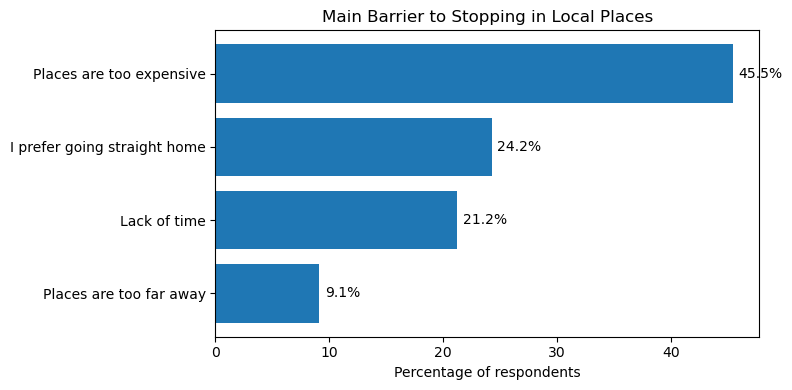

In [22]:
for col in selected_nominal_cols:
    table = make_distribution_table(
        df,
        col,
        label_map=None,
        ordinal=False
    )

    table.to_csv(table_dir / f"{col}_distribution.csv", index=False)

    print(f"\n--- {chart_titles[col]} ---")
    print(f"\n--- Variable name: {col} ---")
    display(table)

    plot_bar_chart(
        table,
        title=chart_titles[col],
        output_path=chart_dir / f"{col}_bar_chart.png"
    )